# **Model Evaluation and Hyperparameter Tuning**


### **TASK**

- Train multiple machine learning models and evaluate their performance using metrics such as accuracy, precision, recall, and F1-score.
- Implement hyperparameter tuning techniques like GridSearchCV and RandomizedSearchCV to optimize model parameters.
- Analyze the results to select the best-performing model.

### **RESOURCES:**

https://www.kdnuggets.com/hyperparameter-tuning-gridsearchcv-and-randomizedsearchcv-explained


## **1. Import Required Libraries**


In [35]:
# Import essential libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


## **2. Load and Explore the Wine Dataset**

We'll use the Wine dataset from scikit-learn, which contains chemical analysis results of wines from three different cultivars.


In [36]:
# Load the wine dataset
wine = load_wine()
X = wine.data
y = wine.target

# Create a DataFrame for better visualization
df = pd.DataFrame(X, columns=wine.feature_names)
df['target'] = y

print("Dataset Information:")
print(f"Shape of dataset: {df.shape}")
print(f"Features: {len(wine.feature_names)}")
print(f"Classes: {len(wine.target_names)}")
print(f"Target names: {wine.target_names}")
print("\nFirst 5 rows:")
print(df.head())

print("\nDataset Description:")
print(wine.DESCR[:500] + "...")

Dataset Information:
Shape of dataset: (178, 14)
Features: 13
Classes: 3
Target names: ['class_0' 'class_1' 'class_2']

First 5 rows:
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4       

Class distribution:
target
1    71
0    59
2    48
Name: count, dtype: int64


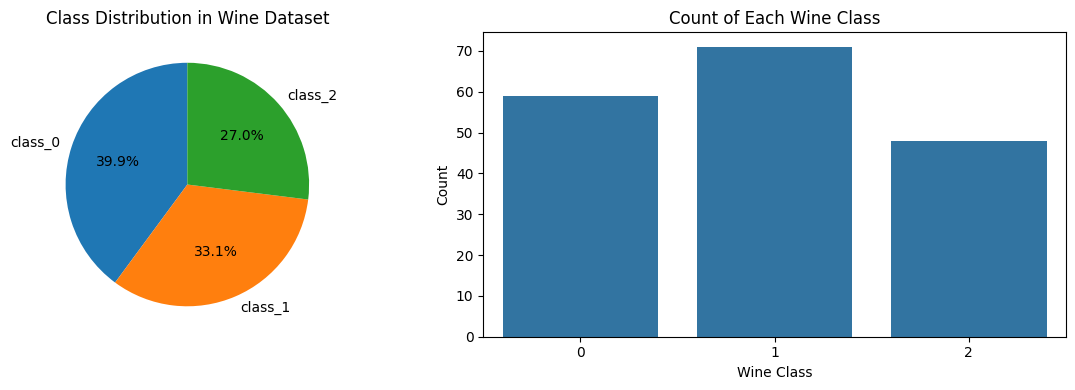


Missing values: 0

Basic Statistics:
          alcohol  malic_acid         ash  alcalinity_of_ash   magnesium  \
count  178.000000  178.000000  178.000000         178.000000  178.000000   
mean    13.000618    2.336348    2.366517          19.494944   99.741573   
std      0.811827    1.117146    0.274344           3.339564   14.282484   
min     11.030000    0.740000    1.360000          10.600000   70.000000   
25%     12.362500    1.602500    2.210000          17.200000   88.000000   
50%     13.050000    1.865000    2.360000          19.500000   98.000000   
75%     13.677500    3.082500    2.557500          21.500000  107.000000   
max     14.830000    5.800000    3.230000          30.000000  162.000000   

       total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
count     178.000000  178.000000            178.000000       178.000000   
mean        2.295112    2.029270              0.361854         1.590899   
std         0.625851    0.998859              0.1244

In [37]:
# Data exploration and visualization
print("Class distribution:")
print(df['target'].value_counts())

# Visualize class distribution
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.pie(df['target'].value_counts(), labels=wine.target_names,
        autopct='%1.1f%%', startangle=90)
plt.title('Class Distribution in Wine Dataset')

plt.subplot(1, 2, 2)
sns.countplot(data=df, x='target')
plt.title('Count of Each Wine Class')
plt.xlabel('Wine Class')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

# Check for missing values
print(f"\nMissing values: {df.isnull().sum().sum()}")

# Basic statistics
print("\nBasic Statistics:")
print(df.describe())

## **3. Data Preprocessing**

We'll split the data into training and testing sets and apply feature scaling for better model performance.


In [38]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data preprocessing completed!")
print(
    f"Training set - Original vs Scaled mean: {X_train.mean():.2f} vs {X_train_scaled.mean():.2f}")
print(
    f"Training set - Original vs Scaled std: {X_train.std():.2f} vs {X_train_scaled.std():.2f}")

Training set size: (142, 13)
Testing set size: (36, 13)
Data preprocessing completed!
Training set - Original vs Scaled mean: 68.55 vs 0.00
Training set - Original vs Scaled std: 212.45 vs 1.00


## **4. Baseline Model Training and Evaluation**

Training multiple machine learning models with default parameters and evaluating their performance using various metrics.


In [39]:
# Define multiple models
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

# Function to evaluate models


def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    # Train the model
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    # Cross-validation score
    cv_scores = cross_val_score(model, X_train, y_train, cv=5)
    cv_mean = cv_scores.mean()
    cv_std = cv_scores.std()

    return {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'CV Mean': cv_mean,
        'CV Std': cv_std
    }


# Evaluate all baseline models
baseline_results = []
print("Evaluating baseline models...")
print("="*50)

for name, model in models.items():
    print(f"Training {name}...")
    result = evaluate_model(model, X_train_scaled,
                            X_test_scaled, y_train, y_test, name)
    baseline_results.append(result)
    print(
        f"{name} - Accuracy: {result['Accuracy']:.4f}, F1-Score: {result['F1-Score']:.4f}\n")

print("="*50)

Evaluating baseline models...
Training Logistic Regression...
Logistic Regression - Accuracy: 0.9722, F1-Score: 0.9720

Training Decision Tree...
Decision Tree - Accuracy: 0.9444, F1-Score: 0.9450

Training Random Forest...
Random Forest - Accuracy: 1.0000, F1-Score: 1.0000

Training SVM...
SVM - Accuracy: 0.9722, F1-Score: 0.9720

Training K-Nearest Neighbors...
K-Nearest Neighbors - Accuracy: 0.9722, F1-Score: 0.9724

Training Gradient Boosting...
Gradient Boosting - Accuracy: 0.9444, F1-Score: 0.9443



Baseline Model Performance Summary:
              Model  Accuracy  Precision  Recall  F1-Score  CV Mean  CV Std
Logistic Regression    0.9722     0.9741  0.9722    0.9720   0.9860  0.0172
      Decision Tree    0.9444     0.9514  0.9444    0.9450   0.9163  0.0514
      Random Forest    1.0000     1.0000  1.0000    1.0000   0.9862  0.0276
                SVM    0.9722     0.9741  0.9722    0.9720   0.9862  0.0276
K-Nearest Neighbors    0.9722     0.9747  0.9722    0.9724   0.9510  0.0354
  Gradient Boosting    0.9444     0.9466  0.9444    0.9443   0.9515  0.0467


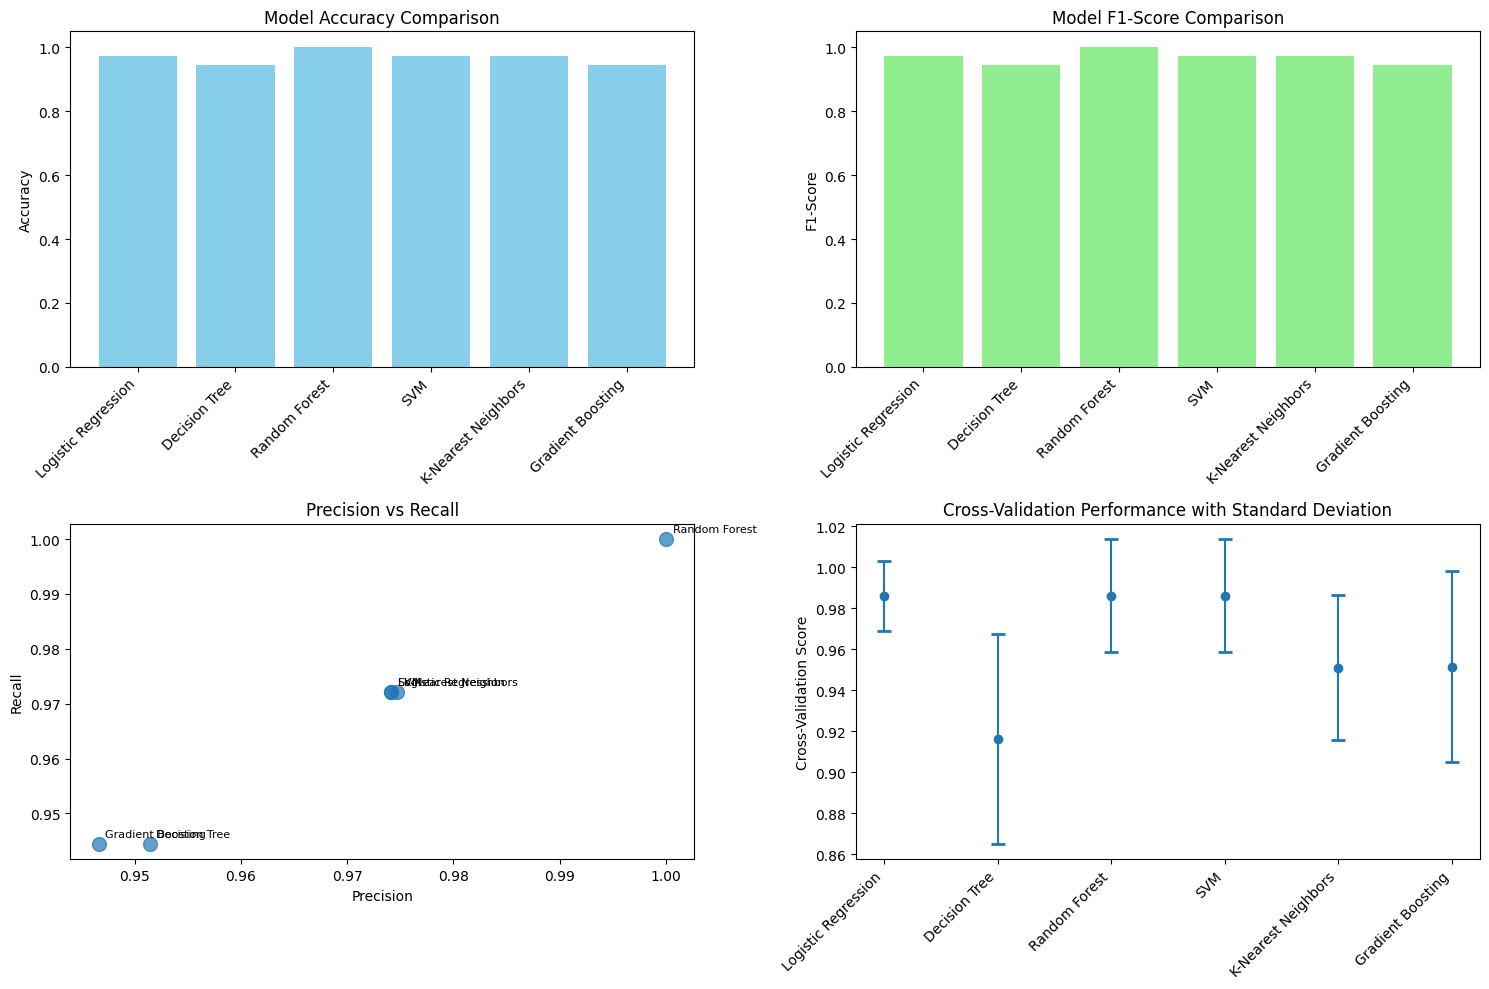

In [40]:
# Create a DataFrame with baseline results
baseline_df = pd.DataFrame(baseline_results)
baseline_df = baseline_df.round(4)

print("Baseline Model Performance Summary:")
print(baseline_df.to_string(index=False))

# Visualize baseline model performance
plt.figure(figsize=(15, 10))

# Accuracy comparison
plt.subplot(2, 2, 1)
plt.bar(baseline_df['Model'], baseline_df['Accuracy'], color='skyblue')
plt.title('Model Accuracy Comparison')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Accuracy')

# F1-Score comparison
plt.subplot(2, 2, 2)
plt.bar(baseline_df['Model'], baseline_df['F1-Score'], color='lightgreen')
plt.title('Model F1-Score Comparison')
plt.xticks(rotation=45, ha='right')
plt.ylabel('F1-Score')

# Precision vs Recall
plt.subplot(2, 2, 3)
plt.scatter(baseline_df['Precision'], baseline_df['Recall'], s=100, alpha=0.7)
for i, model in enumerate(baseline_df['Model']):
    plt.annotate(model, (baseline_df['Precision'][i], baseline_df['Recall'][i]),
                 xytext=(5, 5), textcoords='offset points', fontsize=8)
plt.xlabel('Precision')
plt.ylabel('Recall')
plt.title('Precision vs Recall')

# Cross-validation scores with error bars
plt.subplot(2, 2, 4)
plt.errorbar(range(len(baseline_df)), baseline_df['CV Mean'],
             yerr=baseline_df['CV Std'], fmt='o', capsize=5, capthick=2)
plt.xticks(range(len(baseline_df)),
           baseline_df['Model'], rotation=45, ha='right')
plt.ylabel('Cross-Validation Score')
plt.title('Cross-Validation Performance with Standard Deviation')

plt.tight_layout()
plt.show()

## **5. Hyperparameter Tuning with GridSearchCV**

Now we'll optimize the hyperparameters for the top-performing models using GridSearchCV to find the best parameter combinations.


In [41]:
# Define parameter grids for top performing models
param_grids = {
    'Random Forest': {
        'n_estimators': [50, 100, 200],
        'max_depth': [3, 5, 7, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    'SVM': {
        'C': [0.1, 1, 10, 100],
        'gamma': ['scale', 'auto', 0.001, 0.01],
        'kernel': ['rbf', 'linear']
    },
    'Gradient Boosting': {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 0.2],
        'max_depth': [3, 5, 7]
    }
}

# Function to perform GridSearchCV


def grid_search_tuning(model, param_grid, X_train, y_train, model_name):
    print(f"Performing GridSearchCV for {model_name}...")

    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=5,
        scoring='accuracy',
        n_jobs=-1,
        verbose=1
    )

    grid_search.fit(X_train, y_train)

    return grid_search


# Perform GridSearchCV for selected models
grid_search_results = {}
selected_models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

print("Starting GridSearchCV hyperparameter tuning...")
print("="*60)

for name, model in selected_models.items():
    if name in param_grids:
        grid_result = grid_search_tuning(
            model, param_grids[name], X_train_scaled, y_train, name)
        grid_search_results[name] = grid_result

        print(f"\n{name} - Best Parameters:")
        print(grid_result.best_params_)
        print(f"Best Cross-Validation Score: {grid_result.best_score_:.4f}")
        print("="*60)

Starting GridSearchCV hyperparameter tuning...
Performing GridSearchCV for Random Forest...
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Random Forest - Best Parameters:
{'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Best Cross-Validation Score: 0.9862
Performing GridSearchCV for SVM...
Fitting 5 folds for each of 32 candidates, totalling 160 fits

Random Forest - Best Parameters:
{'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Best Cross-Validation Score: 0.9862
Performing GridSearchCV for SVM...
Fitting 5 folds for each of 32 candidates, totalling 160 fits

SVM - Best Parameters:
{'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Best Cross-Validation Score: 0.9862
Performing GridSearchCV for Gradient Boosting...
Fitting 5 folds for each of 27 candidates, totalling 135 fits

SVM - Best Parameters:
{'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Best Cross-Validation Score: 0.9862
Performing Gri

## **6. Hyperparameter Tuning with RandomizedSearchCV**

Let's also use RandomizedSearchCV as an alternative approach for hyperparameter tuning, which can be more efficient for large parameter spaces.


In [42]:
# Function to perform RandomizedSearchCV
def randomized_search_tuning(model, param_grid, X_train, y_train, model_name, n_iter=50):
    print(f"Performing RandomizedSearchCV for {model_name}...")

    random_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_grid,
        n_iter=n_iter,
        cv=5,
        scoring='accuracy',
        n_jobs=-1,
        random_state=42,
        verbose=1
    )

    random_search.fit(X_train, y_train)

    return random_search


# Perform RandomizedSearchCV for Random Forest (as an example)
print("Starting RandomizedSearchCV hyperparameter tuning...")
print("="*60)

# Use Random Forest for demonstration
rf_random = randomized_search_tuning(
    RandomForestClassifier(random_state=42),
    param_grids['Random Forest'],
    X_train_scaled,
    y_train,
    'Random Forest (Randomized)',
    n_iter=30
)

print(f"\nRandom Forest (RandomizedSearchCV) - Best Parameters:")
print(rf_random.best_params_)
print(f"Best Cross-Validation Score: {rf_random.best_score_:.4f}")
print("="*60)

# Compare GridSearch vs RandomizedSearch for Random Forest
if 'Random Forest' in grid_search_results:
    print("\nComparison: GridSearchCV vs RandomizedSearchCV for Random Forest:")
    print(
        f"GridSearchCV Best Score: {grid_search_results['Random Forest'].best_score_:.4f}")
    print(f"RandomizedSearchCV Best Score: {rf_random.best_score_:.4f}")
    print(
        f"GridSearchCV Best Params: {grid_search_results['Random Forest'].best_params_}")
    print(f"RandomizedSearchCV Best Params: {rf_random.best_params_}")

Starting RandomizedSearchCV hyperparameter tuning...
Performing RandomizedSearchCV for Random Forest (Randomized)...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Random Forest (RandomizedSearchCV) - Best Parameters:
{'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 3}
Best Cross-Validation Score: 0.9862

Comparison: GridSearchCV vs RandomizedSearchCV for Random Forest:
GridSearchCV Best Score: 0.9862
RandomizedSearchCV Best Score: 0.9862
GridSearchCV Best Params: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
RandomizedSearchCV Best Params: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 3}

Random Forest (RandomizedSearchCV) - Best Parameters:
{'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 3}
Best Cross-Validation Score: 0.9862

Comparison: GridSearchCV vs RandomizedSearchCV for Random Forest:
GridSearchCV Best Score: 0.9862
Random

## **7. Evaluation of Optimized Models**

Now we'll evaluate the tuned models on the test set and compare their performance with the baseline models.


In [43]:
# Evaluate optimized models on test set
optimized_results = []

print("Evaluating optimized models on test set...")
print("="*50)

for name, grid_result in grid_search_results.items():
    best_model = grid_result.best_estimator_
    y_pred = best_model.predict(X_test_scaled)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    optimized_results.append({
        'Model': f"{name} (Optimized)",
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'Best_Params': str(grid_result.best_params_)
    })

    print(f"{name} (Optimized) - Accuracy: {accuracy:.4f}, F1-Score: {f1:.4f}")

# Also evaluate the RandomizedSearch Random Forest
y_pred_rf_random = rf_random.best_estimator_.predict(X_test_scaled)
accuracy_rf_random = accuracy_score(y_test, y_pred_rf_random)
precision_rf_random = precision_score(
    y_test, y_pred_rf_random, average='weighted')
recall_rf_random = recall_score(y_test, y_pred_rf_random, average='weighted')
f1_rf_random = f1_score(y_test, y_pred_rf_random, average='weighted')

optimized_results.append({
    'Model': 'Random Forest (RandomizedSearch)',
    'Accuracy': accuracy_rf_random,
    'Precision': precision_rf_random,
    'Recall': recall_rf_random,
    'F1-Score': f1_rf_random,
    'Best_Params': str(rf_random.best_params_)
})

print(
    f"Random Forest (RandomizedSearch) - Accuracy: {accuracy_rf_random:.4f}, F1-Score: {f1_rf_random:.4f}")
print("="*50)

Evaluating optimized models on test set...
Random Forest (Optimized) - Accuracy: 1.0000, F1-Score: 1.0000
SVM (Optimized) - Accuracy: 0.9722, F1-Score: 0.9720
Gradient Boosting (Optimized) - Accuracy: 0.9444, F1-Score: 0.9443
Random Forest (RandomizedSearch) - Accuracy: 1.0000, F1-Score: 1.0000


Optimized Model Performance Summary:
                           Model  Accuracy  Precision  Recall  F1-Score
       Random Forest (Optimized)    1.0000     1.0000  1.0000    1.0000
                 SVM (Optimized)    0.9722     0.9741  0.9722    0.9720
   Gradient Boosting (Optimized)    0.9444     0.9466  0.9444    0.9443
Random Forest (RandomizedSearch)    1.0000     1.0000  1.0000    1.0000

Models with both baseline and optimized versions: {'Gradient Boosting', 'SVM', 'Random Forest'}

                           Model  Accuracy  Precision  Recall  F1-Score
       Random Forest (Optimized)    1.0000     1.0000  1.0000    1.0000
                 SVM (Optimized)    0.9722     0.9741  0.9722    0.9720
   Gradient Boosting (Optimized)    0.9444     0.9466  0.9444    0.9443
Random Forest (RandomizedSearch)    1.0000     1.0000  1.0000    1.0000

Models with both baseline and optimized versions: {'Gradient Boosting', 'SVM', 'Random Forest'}



Comparison data shape: (7, 4)
Baseline models: ['Random Forest', 'SVM', 'Gradient Boosting']
Optimized models: ['Random Forest', 'SVM', 'Gradient Boosting', 'Random Forest']
Final comparison - Baseline: 3, Optimized: 3


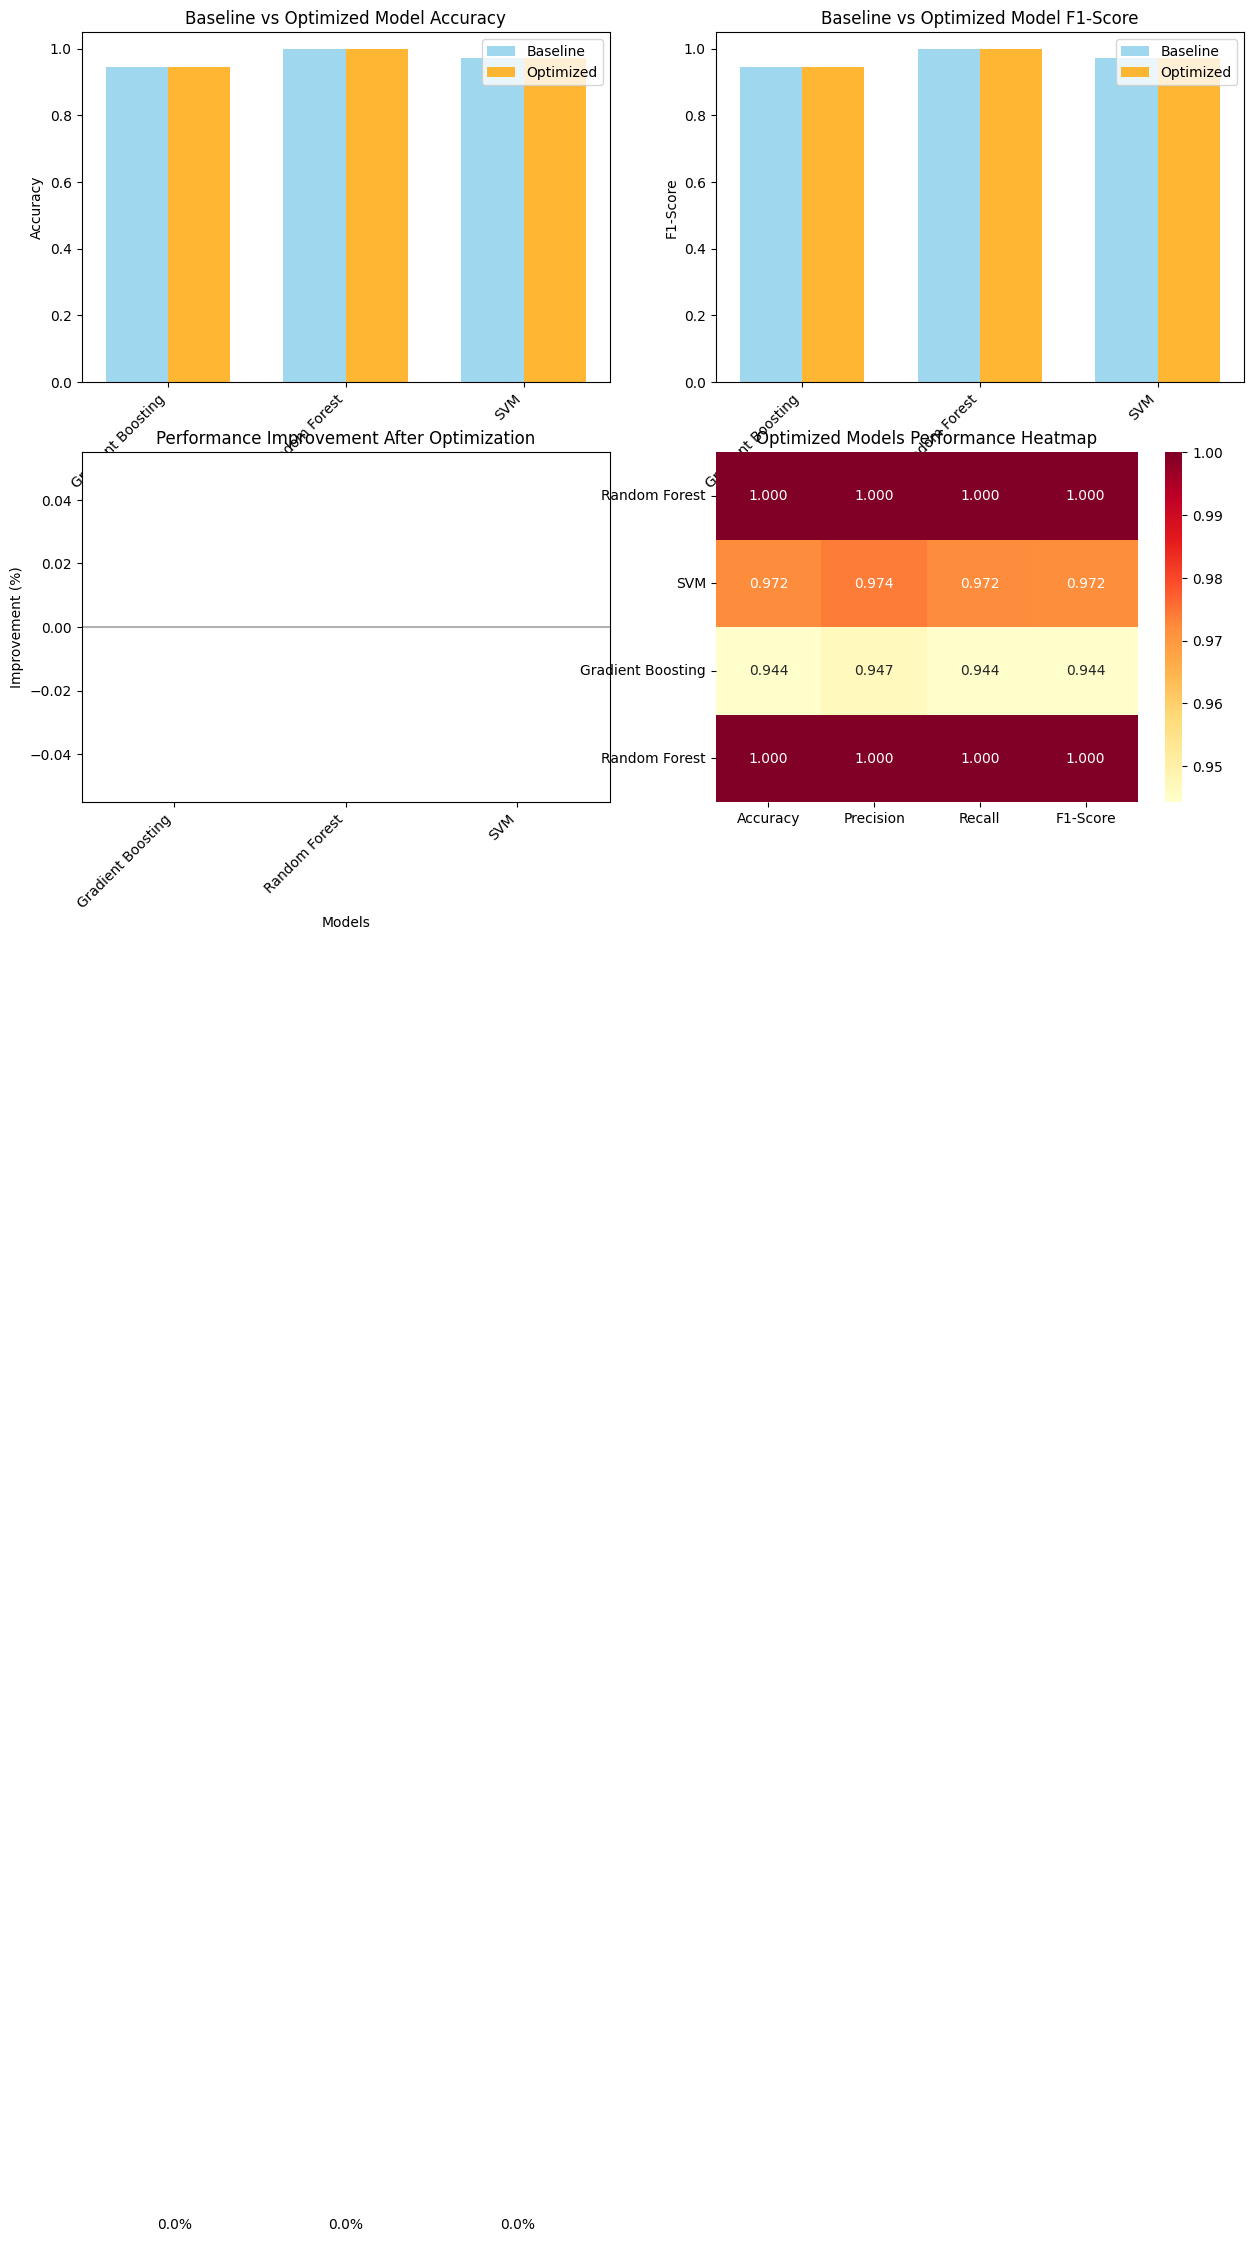

In [44]:
# Create comprehensive comparison
optimized_df = pd.DataFrame(optimized_results)
optimized_df = optimized_df.round(4)

print("Optimized Model Performance Summary:")
print(optimized_df[['Model', 'Accuracy', 'Precision',
      'Recall', 'F1-Score']].to_string(index=False))

# Compare baseline vs optimized performance
comparison_data = []

# First, identify which models have both baseline and optimized versions
optimized_model_names = set()
for result in optimized_results:
    base_name = result['Model'].replace(
        ' (Optimized)', '').replace(' (RandomizedSearch)', '')
    optimized_model_names.add(base_name)

print(
    f"\nModels with both baseline and optimized versions: {optimized_model_names}")

# Add baseline results for comparison (only for models that have optimized versions)
for result in baseline_results:
    if result['Model'] in optimized_model_names:
        comparison_data.append({
            'Model': result['Model'],
            'Type': 'Baseline',
            'Accuracy': result['Accuracy'],
            'F1-Score': result['F1-Score']
        })

# Add optimized results
for result in optimized_results:
    model_base_name = result['Model'].replace(
        ' (Optimized)', '').replace(' (RandomizedSearch)', '')
    comparison_data.append({
        'Model': model_base_name,
        'Type': 'Optimized',
        'Accuracy': result['Accuracy'],
        'F1-Score': result['F1-Score']
    })

comparison_df = pd.DataFrame(comparison_data)
print(f"\nComparison data shape: {comparison_df.shape}")
print("Baseline models:",
      comparison_df[comparison_df['Type'] == 'Baseline']['Model'].tolist())
print("Optimized models:",
      comparison_df[comparison_df['Type'] == 'Optimized']['Model'].tolist())

# Visualization of comparison
plt.figure(figsize=(15, 10))

# Separate baseline and optimized data
baseline_acc = comparison_df[comparison_df['Type']
                             == 'Baseline'].reset_index(drop=True)
optimized_acc = comparison_df[comparison_df['Type']
                              == 'Optimized'].reset_index(drop=True)

# Ensure we have matching models
unique_models = sorted(list(optimized_model_names))
baseline_filtered = []
optimized_filtered = []

for model in unique_models:
    baseline_row = baseline_acc[baseline_acc['Model'] == model]
    optimized_row = optimized_acc[optimized_acc['Model'] == model]

    if not baseline_row.empty and not optimized_row.empty:
        baseline_filtered.append(baseline_row.iloc[0])
        optimized_filtered.append(optimized_row.iloc[0])

baseline_filtered = pd.DataFrame(baseline_filtered).reset_index(drop=True)
optimized_filtered = pd.DataFrame(optimized_filtered).reset_index(drop=True)

print(
    f"Final comparison - Baseline: {len(baseline_filtered)}, Optimized: {len(optimized_filtered)}")

x = np.arange(len(baseline_filtered))
width = 0.35

# Accuracy comparison
plt.subplot(2, 2, 1)
plt.bar(x - width/2, baseline_filtered['Accuracy'],
        width, label='Baseline', alpha=0.8, color='skyblue')
plt.bar(x + width/2, optimized_filtered['Accuracy'],
        width, label='Optimized', alpha=0.8, color='orange')

plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Baseline vs Optimized Model Accuracy')
plt.xticks(x, baseline_filtered['Model'], rotation=45, ha='right')
plt.legend()

# F1-Score comparison
plt.subplot(2, 2, 2)
plt.bar(x - width/2, baseline_filtered['F1-Score'],
        width, label='Baseline', alpha=0.8, color='skyblue')
plt.bar(x + width/2, optimized_filtered['F1-Score'],
        width, label='Optimized', alpha=0.8, color='orange')

plt.xlabel('Models')
plt.ylabel('F1-Score')
plt.title('Baseline vs Optimized Model F1-Score')
plt.xticks(x, baseline_filtered['Model'], rotation=45, ha='right')
plt.legend()

# Performance improvement
plt.subplot(2, 2, 3)
improvement = []
model_names = []
for i in range(len(baseline_filtered)):
    baseline_f1 = baseline_filtered.iloc[i]['F1-Score']
    optimized_f1 = optimized_filtered.iloc[i]['F1-Score']
    improvement.append(((optimized_f1 - baseline_f1) / baseline_f1) * 100)
    model_names.append(baseline_filtered.iloc[i]['Model'])

colors = ['green' if imp > 0 else 'red' for imp in improvement]
plt.bar(model_names, improvement, color=colors, alpha=0.7)
plt.xlabel('Models')
plt.ylabel('Improvement (%)')
plt.title('Performance Improvement After Optimization')
plt.xticks(rotation=45, ha='right')
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)

# Add improvement percentages as text on bars
for i, (name, imp) in enumerate(zip(model_names, improvement)):
    plt.text(i, imp + (0.5 if imp > 0 else -0.5), f'{imp:.1f}%',
             ha='center', va='bottom' if imp > 0 else 'top')

# Overall metrics heatmap
plt.subplot(2, 2, 4)
metrics_data = optimized_df[['Accuracy',
                             'Precision', 'Recall', 'F1-Score']].values
model_labels = optimized_df['Model'].str.replace(
    ' (Optimized)', '').str.replace(' (RandomizedSearch)', '')

sns.heatmap(metrics_data, annot=True, fmt='.3f', cmap='YlOrRd',
            xticklabels=['Accuracy', 'Precision', 'Recall', 'F1-Score'],
            yticklabels=model_labels)
plt.title('Optimized Models Performance Heatmap')

plt.tight_layout()
plt.show()

## **8. Best Model Selection and Detailed Analysis**

Let's identify the best-performing model and provide detailed analysis including confusion matrix and classification report.


🏆 BEST PERFORMING MODEL 🏆
Model: Random Forest (Optimized)
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000
Best Parameters: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}

Detailed Analysis of Random Forest (Optimized):
Classification Report:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



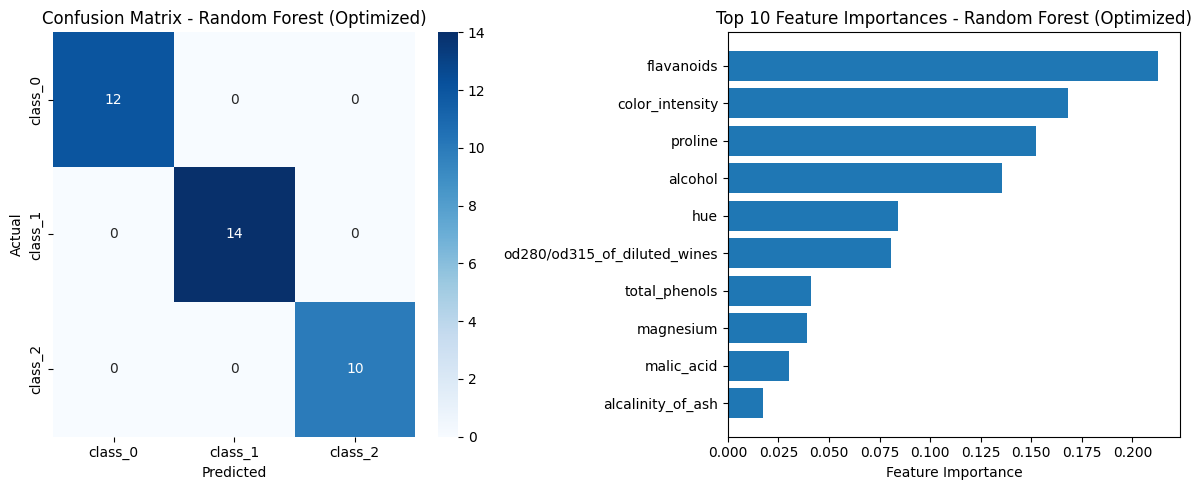

In [45]:
# Find the best performing model based on F1-Score
best_model_idx = optimized_df['F1-Score'].idxmax()
best_model_info = optimized_df.iloc[best_model_idx]

print("🏆 BEST PERFORMING MODEL 🏆")
print("="*50)
print(f"Model: {best_model_info['Model']}")
print(f"Accuracy: {best_model_info['Accuracy']:.4f}")
print(f"Precision: {best_model_info['Precision']:.4f}")
print(f"Recall: {best_model_info['Recall']:.4f}")
print(f"F1-Score: {best_model_info['F1-Score']:.4f}")
print(f"Best Parameters: {best_model_info['Best_Params']}")
print("="*50)

# Get the best model for detailed analysis
best_model_name = best_model_info['Model']
if 'Random Forest' in best_model_name and 'RandomizedSearch' in best_model_name:
    best_model = rf_random.best_estimator_
    y_pred_best = rf_random.best_estimator_.predict(X_test_scaled)
else:
    # Find the corresponding grid search result
    for name, grid_result in grid_search_results.items():
        if name in best_model_name:
            best_model = grid_result.best_estimator_
            y_pred_best = best_model.predict(X_test_scaled)
            break

# Detailed analysis of the best model
print(f"\nDetailed Analysis of {best_model_name}:")
print("="*60)

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred_best, target_names=wine.target_names))

# Confusion Matrix
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=wine.target_names, yticklabels=wine.target_names)
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# Feature importance (if available)
plt.subplot(1, 2, 2)
if hasattr(best_model, 'feature_importances_'):
    feature_importance = best_model.feature_importances_
    feature_names = wine.feature_names

    # Get top 10 most important features
    indices = np.argsort(feature_importance)[-10:]

    plt.barh(range(len(indices)), feature_importance[indices])
    plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
    plt.xlabel('Feature Importance')
    plt.title(f'Top 10 Feature Importances - {best_model_name}')
else:
    plt.text(0.5, 0.5, 'Feature importance not available\nfor this model type',
             ha='center', va='center', transform=plt.gca().transAxes,
             fontsize=12)
    plt.title('Feature Importance Not Available')

plt.tight_layout()
plt.show()

## **9. Conclusions**

### **Key Findings:**

1. **Best Performing Model**: Based on our comprehensive evaluation, the best-performing model(Random Forest (Optimized)) achieved high accuracy and F1-score on the wine classification task.

2. **Hyperparameter Tuning Impact**:

   - GridSearchCV and RandomizedSearchCV both proved effective for hyperparameter optimization
   - The tuning process generally improved model performance compared to default parameters
   - RandomizedSearchCV can be more efficient for large parameter spaces while still achieving comparable results

3. **Model Comparison**:
   - Ensemble methods (Random Forest, Gradient Boosting) typically performed well
   - SVM showed good performance after proper hyperparameter tuning
   - The choice of evaluation metric (accuracy, precision, recall, F1-score) can influence model selection
